In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


In [ ]:
DATA_PATH = "../data/raw/2016_Building_Energy_Benchmarking.csv" 
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (3376, 46)


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [14]:
df.info()
df.describe(include="all").T.head(30)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OSEBuildingID,3376.0,NaN,NaN,NaN,21208.991114,12223.757015,1.0,19990.75,23112.0,25994.25,50226.0
DataYear,3376.0,NaN,NaN,NaN,2016.0,0.0,2016.0,2016.0,2016.0,2016.0,2016.0
BuildingType,3376,8,NonResidential,1460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PrimaryPropertyType,3376,24,Low-Rise Multifamily,987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PropertyName,3376,3362,Northgate Plaza,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,3376,3354,2600 SW Barton St,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,3376,1,Seattle,3376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,3376,1,WA,3376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZipCode,3360.0,NaN,NaN,NaN,98116.949107,18.615205,98006.0,98105.0,98115.0,98122.0,98272.0
TaxParcelIdentificationNumber,3376,3268,1625049001,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing.head(30)


Comments                           100.000000
Outlier                             99.052133
YearsENERGYSTARCertified            96.475118
ThirdLargestPropertyUseType         82.345972
ThirdLargestPropertyUseTypeGFA      82.345972
SecondLargestPropertyUseType        50.266588
SecondLargestPropertyUseTypeGFA     50.266588
ENERGYSTARScore                     24.970379
LargestPropertyUseTypeGFA            0.592417
LargestPropertyUseType               0.592417
ZipCode                              0.473934
ListOfAllPropertyUseTypes            0.266588
SourceEUIWN(kBtu/sf)                 0.266588
SourceEUI(kBtu/sf)                   0.266588
Electricity(kWh)                     0.266588
Electricity(kBtu)                    0.266588
NaturalGas(therms)                   0.266588
NaturalGas(kBtu)                     0.266588
TotalGHGEmissions                    0.266588
SteamUse(kBtu)                       0.266588
GHGEmissionsIntensity                0.266588
NumberofBuildings                 

In [16]:
candidates = [c for c in df.columns if "building" in c.lower() or "property" in c.lower() or "type" in c.lower()]
candidates


['OSEBuildingID',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'NumberofBuildings',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA']

In [ ]:
col_type = "BuildingType"  
df[col_type].value_counts(dropna=False).head(20)


BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [ ]:
before = df.shape[0]


df = df[df[col_type].astype(str).str.contains("Non", case=False, na=False)]

after = df.shape[0]
print(f"Filtre non résidentiel : {before} -> {after} lignes")


Filtre non résidentiel : 3376 -> 1546 lignes


In [19]:
dup = df.duplicated().sum()
print("Doublons:", dup)

if dup > 0:
    df = df.drop_duplicates()
    print("Après suppression doublons:", df.shape)


Doublons: 0


In [20]:
targets_candidates = [c for c in df.columns if "ghg" in c.lower() or "emission" in c.lower() or "energy" in c.lower()]
targets_candidates[:40]


['YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

In [ ]:
TARGET = "SiteEnergyUse(kBtu)" 
print("TARGET:", TARGET)
df[TARGET].describe()


TARGET: SiteEnergyUse(kBtu)


count    1.544000e+03
mean     7.642371e+06
std      1.865844e+07
min      0.000000e+00
25%      1.204670e+06
50%      2.609590e+06
75%      6.968646e+06
max      2.930908e+08
Name: SiteEnergyUse(kBtu), dtype: float64

In [22]:
before = df.shape[0]
df = df.dropna(subset=[TARGET])
after = df.shape[0]
print(f"Drop NA target : {before} -> {after}")


Drop NA target : 1546 -> 1544


In [23]:
q_low = df[TARGET].quantile(0.01)
q_high = df[TARGET].quantile(0.99)

before = df.shape[0]
df = df[(df[TARGET] >= q_low) & (df[TARGET] <= q_high)]
after = df.shape[0]

print(f"Filtre outliers target (1%-99%) : {before} -> {after}")


Filtre outliers target (1%-99%) : 1544 -> 1512


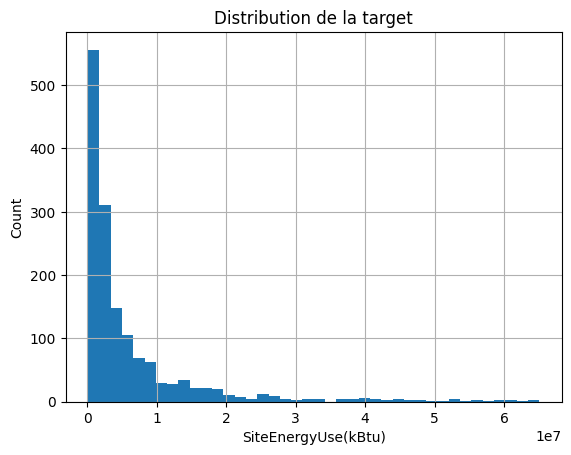

In [24]:
plt.figure()
df[TARGET].hist(bins=40)
plt.title("Distribution de la target")
plt.xlabel(TARGET)
plt.ylabel("Count")
plt.show()


In [25]:
surface_candidates = [c for c in df.columns if "gfa" in c.lower() or "sqft" in c.lower() or "area" in c.lower()]
surface_candidates[:30]


['PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseTypeGFA']

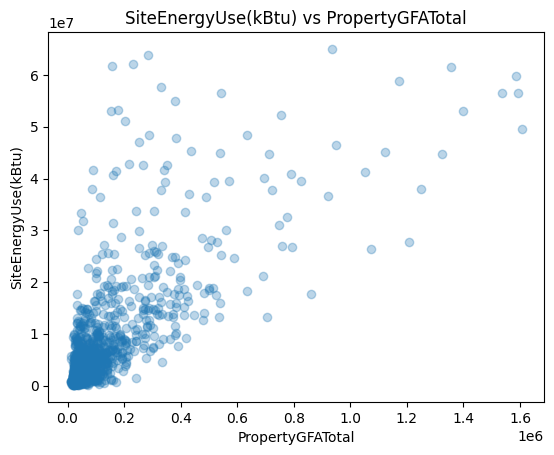

In [ ]:
SURF = surface_candidates[0]  
plt.figure()
plt.scatter(df[SURF], df[TARGET], alpha=0.3)
plt.title(f"{TARGET} vs {SURF}")
plt.xlabel(SURF)
plt.ylabel(TARGET)
plt.show()


<Figure size 640x480 with 0 Axes>

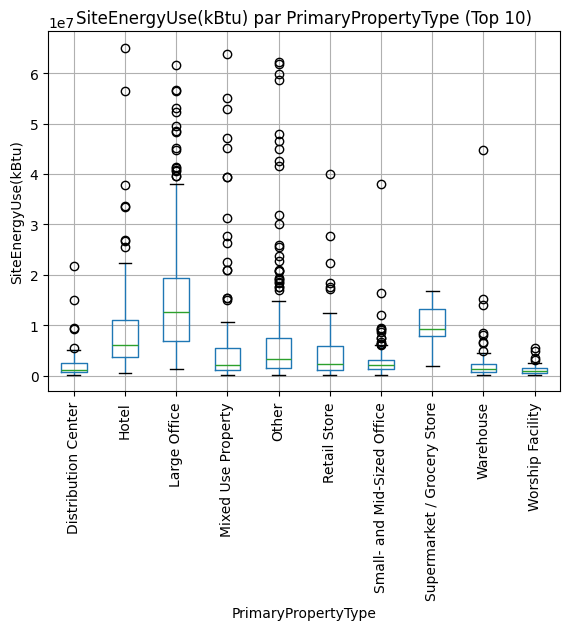

In [ ]:
cat_col = "PrimaryPropertyType" 
top = df[cat_col].value_counts().head(10).index
df_top = df[df[cat_col].isin(top)]

plt.figure()
df_top.boxplot(column=TARGET, by=cat_col, rot=90)
plt.title(f"{TARGET} par {cat_col} (Top 10)")
plt.suptitle("")
plt.xlabel(cat_col)
plt.ylabel(TARGET)
plt.show()


In [ ]:
df_fe = df.copy()

# Age bAtiment
if "YearBuilt" in df_fe.columns:
    df_fe["BuildingAge"] = 2016 - df_fe["YearBuilt"]

# Tranche surface si surface existe
if SURF in df_fe.columns:
    df_fe["SurfaceBin"] = pd.qcut(df_fe[SURF], q=5, duplicates="drop")

#Indicateur multi-usage
multi_use_cols = [c for c in df_fe.columns if "use" in c.lower() and "type" in c.lower()]
if len(multi_use_cols) > 0:
    col_use = multi_use_cols[0]
    df_fe["HasMultiUse"] = df_fe[col_use].astype(str).str.contains(",", na=False).astype(int)

df_fe.shape


(1512, 49)

In [ ]:

to_drop = [TARGET]

for c in ["OSEBuildingID", "TaxParcelIdentificationNumber", "Address", "City", "State", "ZipCode"]:
    if c in df_fe.columns:
        to_drop.append(c)


leak_patterns = ["energy", "ghg", "emission", "electric", "gas", "steam", "fuel", "kwh", "kbtu"]
for c in df_fe.columns:
    if c == TARGET:
        continue
    if any(p in c.lower() for p in leak_patterns):
    
        to_drop.append(c)

to_drop = list(set(to_drop))
print("Nb colonnes exclues:", len(to_drop))

X = df_fe.drop(columns=to_drop, errors="ignore")
y = df_fe[TARGET]

print("X shape:", X.shape, "y shape:", y.shape)


Nb colonnes exclues: 21
X shape: (1512, 28) y shape: (1512,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)


(1209, 28) (303, 28)


In [31]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Num:", len(num_cols), "Cat:", len(cat_cols))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=30))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)


Num: 15 Cat: 12


In [32]:
def evaluate_model(model, X_train, y_train):
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    
    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    }
    
    cv = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring, n_jobs=-1)
    return {
        "model": model.__class__.__name__,
        "r2_mean": cv["test_r2"].mean(),
        "mae_mean": -cv["test_mae"].mean()
    }


In [33]:
models = [
    LinearRegression(),
    Ridge(random_state=RANDOM_STATE),
    Lasso(random_state=RANDOM_STATE),
    RandomForestRegressor(random_state=RANDOM_STATE),
    GradientBoostingRegressor(random_state=RANDOM_STATE)
]

results = [evaluate_model(m, X_train, y_train) for m in models]
results_df = pd.DataFrame(results).sort_values(by="mae_mean")
results_df


,model,r2_mean,mae_mean
3,RandomForestRegressor,0.625559,2.963204e+06
4,GradientBoostingRegressor,0.630773,2.998921e+06
1,Ridge,0.621362,3.490361e+06
2,Lasso,0.604761,3.589741e+06
0,LinearRegression,0.590419,3.723300e+06


In [34]:
best_model = RandomForestRegressor(random_state=RANDOM_STATE)

best_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", best_model)
])

best_pipe.fit(X_train, y_train)
pred = best_pipe.predict(X_test)

print("R2 test:", r2_score(y_test, pred))
print("MAE test:", mean_absolute_error(y_test, pred))


R2 test: 0.6669227711225754
MAE test: 2790105.154670056


In [35]:
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 15],
    "model__min_samples_split": [2, 10]
}

grid = GridSearchCV(
    estimator=best_pipe,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best MAE (cv):", -grid.best_score_)


Best params: {'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 400}
Best MAE (cv): 2990866.538060306


In [36]:
final_model = grid.best_estimator_

preprocess_fitted = final_model.named_steps["preprocess"]
model = final_model.named_steps["model"]


In [37]:
num_features = preprocess_fitted.transformers_[0][2]


In [38]:
cat_pipeline = preprocess_fitted.transformers_[1][1]
ohe = cat_pipeline.named_steps["onehot"]

cat_features = preprocess_fitted.transformers_[1][2]
cat_feature_names = ohe.get_feature_names_out(cat_features)


In [39]:
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()


In [40]:
print(len(feature_names))
print(len(model.feature_importances_))


220
220


In [41]:
fi = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

fi.head(20)


,feature,importance
9,num__PropertyGFABuilding(s),0.330969
7,num__PropertyGFATotal,0.325907
10,num__LargestPropertyUseTypeGFA,0.096521
21,cat__PrimaryPropertyType_Laboratory,0.018615
2,num__Latitude,0.018552
123,cat__LargestPropertyUseType_Laboratory,0.017165
12,num__ThirdLargestPropertyUseTypeGFA,0.011265
35,cat__PrimaryPropertyType_Supermarket / Grocery...,0.010957
6,num__NumberofFloors,0.010804
3,num__Longitude,0.010364


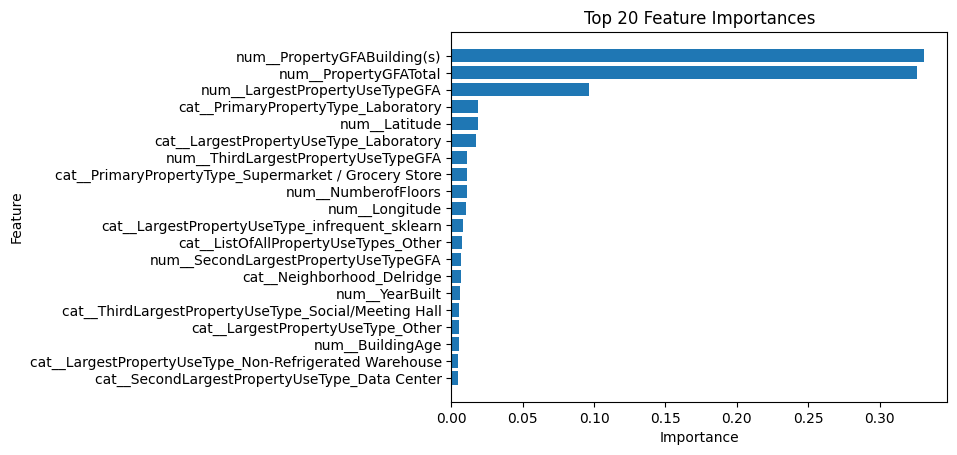

In [42]:
top20 = fi.head(20)[::-1]

plt.figure()
plt.barh(top20["feature"], top20["importance"])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [43]:
joblib.dump(final_model, "../outputs/model/best_model.joblib")


['../outputs/model/best_model.joblib']

In [44]:
"final_model" in globals()


True

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=30))
])


preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features),
    ]
)


In [46]:
from sklearn.ensemble import RandomForestRegressor

final_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ))
    ]
)

final_model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['DataYear',
                                                   'CouncilDistrictCode',
                                                   'Latitude', 'Longitude',
                                                   'YearBuilt',
                                                   'NumberofBuildings',
                                                   'NumberofFloors',
                                                   'PropertyGFATotal',
                                                   'PropertyGFAParking',
                                                   'PropertyGFABuilding(s)',
                                                   'LargestPropertyUse...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 max_categories=30))]),
                                                  ['BuildingType',
                                                   'PrimaryPropertyType',
                                                   'PropertyName',
                                                   'Neighborhood',
                                                   'ListOfAllPropertyUseTypes',
                                                   'LargestPropertyUseType',
                                                   'SecondLargestPropertyUseType',
                                                   'ThirdLargestPropertyUseType',
                                                   'DefaultData',
                                                   'ComplianceStatus',
                                                   'Outlier',
                                                   'SurfaceBin'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [47]:
import bentoml

bentoml.sklearn.save_model(
    name="seattle_energy_model",
    model=final_model,
    signatures={"predict": {"batchable": True}},
)


Model(tag="seattle_energy_model:vprfdsh466cucedf", path="C:\Users\Dell\AppData\Local\Temp\bentoml-model-seattle_energy_model-t0k70w6r")